## **Data Preprocesing**

In [116]:
# importing required libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
from os import path

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, accuracy_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from os import path
import random
random.seed(42)

**Loading the Dataset:**

In [117]:
df = pd.read_csv('UNSW_NB15.csv')

print(df.head())

   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_cat  \
0                 0   

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

**Hadling Missing Data:**

In [119]:
#Filtering the rows where the 'service' column has the value '-' and replacing with Nan
df[df['service']=='-']
df['service'].replace('-',np.nan,inplace=True)

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/3256053272.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['service'].replace('-',np.nan,inplace=True)


In [120]:
#Dropping irrelevant columns or rows with excessive missing data
df.drop('service', axis=1, inplace=True)
print(df.isnull().sum())

id                   0
dur                  0
proto                0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat           0
label      

In [121]:
# Exploring the data structure
print("Data shape after cleaning:", df.shape)
print("Attack categories:", df['attack_cat'].value_counts())
print("State values:", df['state'].value_counts())

Data shape after cleaning: (175341, 44)
Attack categories: attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64
State values: state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64


**Handling Duplicates**

In [122]:
# Checking if there are any duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate entries: {duplicate_count}")

Number of duplicate entries: 0


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   state              175341 non-null  object 
 4   spkts              175341 non-null  int64  
 5   dpkts              175341 non-null  int64  
 6   sbytes             175341 non-null  int64  
 7   dbytes             175341 non-null  int64  
 8   rate               175341 non-null  float64
 9   sttl               175341 non-null  int64  
 10  dttl               175341 non-null  int64  
 11  sload              175341 non-null  float64
 12  dload              175341 non-null  float64
 13  sloss              175341 non-null  int64  
 14  dloss              175341 non-null  int64  
 15  sinpkt             175341 non-null  float64
 16  di

**Handling Outliers**

In [124]:
# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)  # 25th percentile (Q1)
    Q3 = df[column].quantile(0.75)  # 75th percentile (Q3)
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 3 * IQR  # Lower bound for outliers
    upper_bound = Q3 + 3 * IQR  # Upper bound for outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# List of numerical columns to consider for outlier detection
numerical_columns = ['spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']

# Create a copy of the original dataframe for outlier removal process
df = df.copy()

# Apply IQR-based outlier removal for each column in the list
for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

# Display the shape of the dataframe after outlier removal
print(f"Shape after outlier removal: {df.shape}")

Shape after outlier removal: (124279, 44)


**Univariate Analysis**

**Countplot for attack categories**

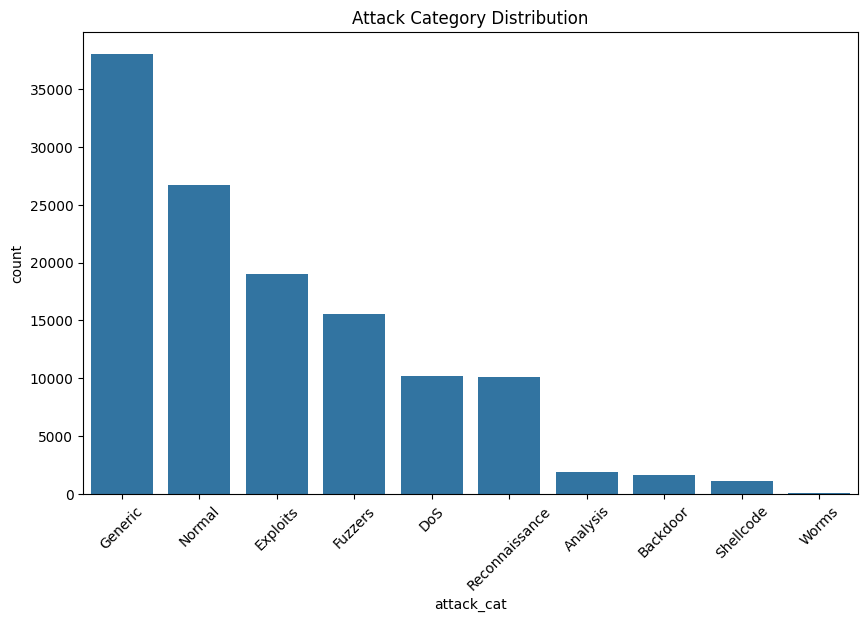

In [125]:
plt.figure(figsize=(10, 6))
sns.countplot(x='attack_cat', data=df, order=df['attack_cat'].value_counts().index)
plt.title('Attack Category Distribution')
plt.xticks(rotation=45)
plt.show()

**Pie chart for normal vs abnormal traffic distribution**

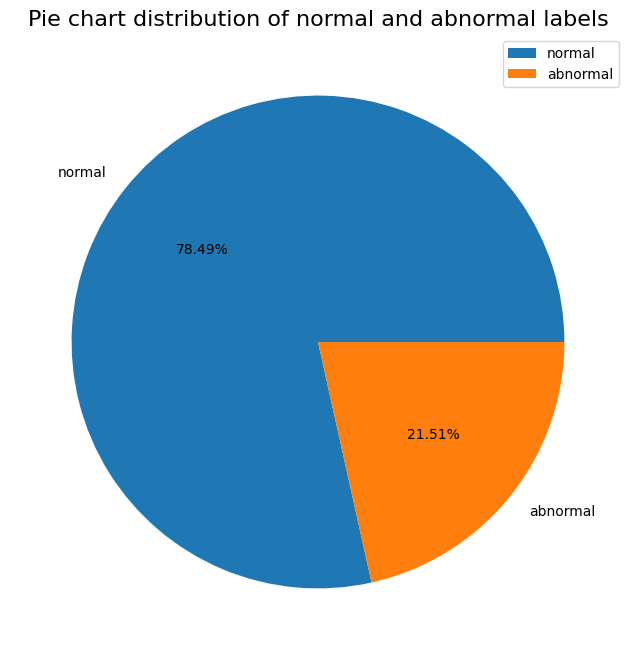

In [126]:
plt.figure(figsize=(8,8))
plt.pie(df.label.value_counts(),labels=['normal','abnormal'],autopct='%0.2f%%')
plt.title("Pie chart distribution of normal and abnormal labels",fontsize=16)
plt.legend()
plt.show()

**Pie chart distribution of multi-class labels**

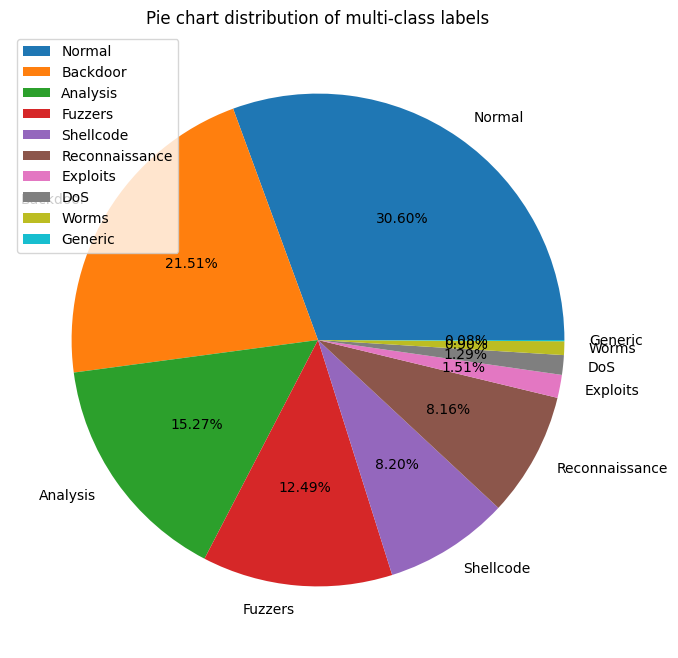

In [127]:
plt.figure(figsize=(8,8))
plt.pie(df.attack_cat.value_counts(),labels=df.attack_cat.unique(),autopct='%0.2f%%')
plt.title('Pie chart distribution of multi-class labels')
plt.legend(loc='best')
plt.show()

**Bivariate Analysis**

**Boxplot for Source Packets and Destination Packets across Attack Categories**

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/1243794649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attack_cat', y='spkts', data=df, palette='pastel')


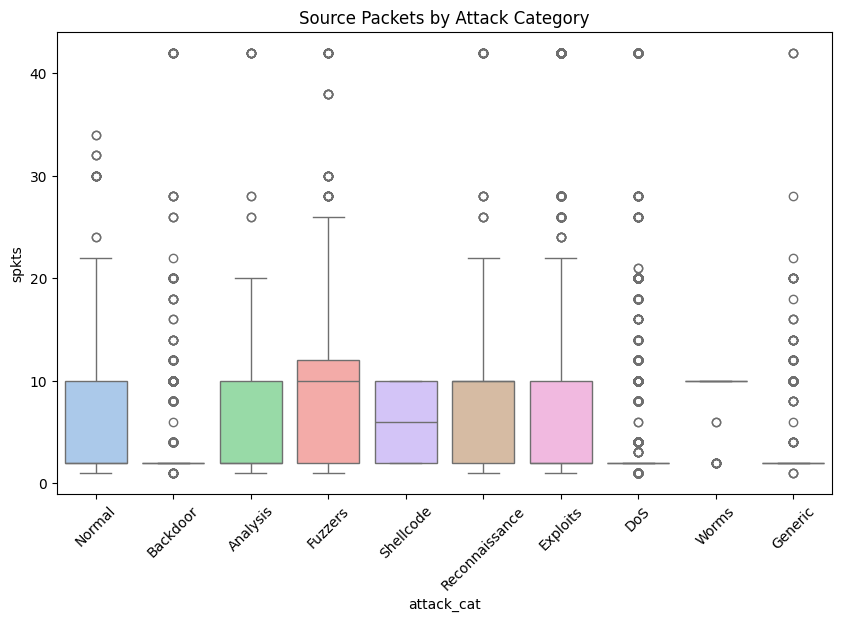

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/1243794649.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='attack_cat', y='dpkts', data=df, palette='pastel')


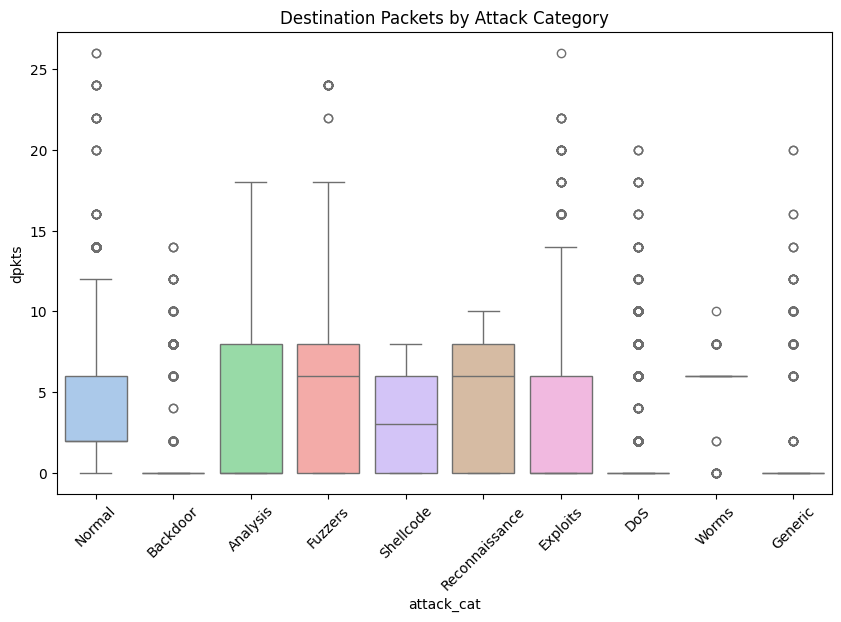

In [128]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='attack_cat', y='spkts', data=df, palette='pastel')
plt.title('Source Packets by Attack Category')
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(x='attack_cat', y='dpkts', data=df, palette='pastel')
plt.title('Destination Packets by Attack Category')
plt.xticks(rotation=45)
plt.show()

**Violin plot for Rate Distribution across Attack Categories**

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/2880080720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='attack_cat', y='rate', data=df, palette='muted')


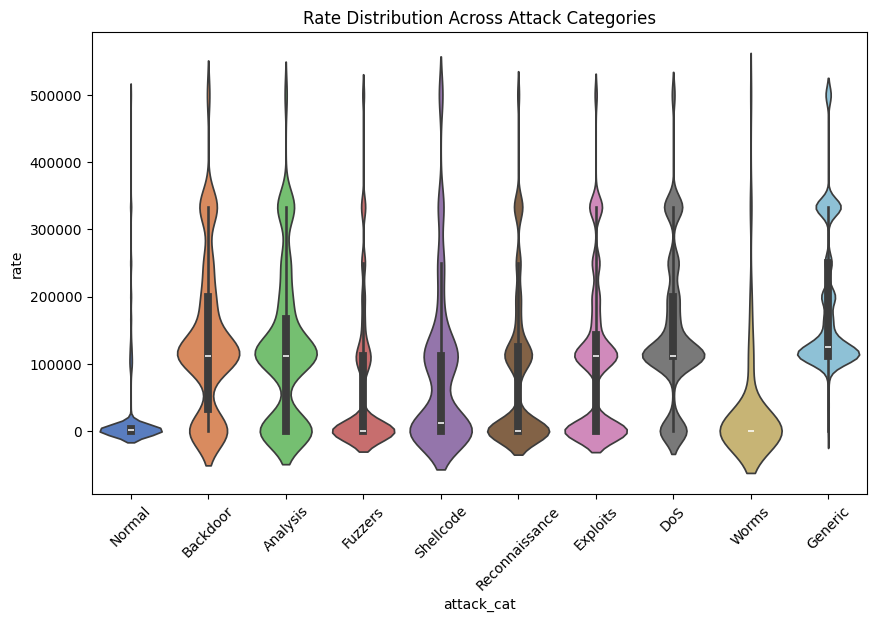

In [129]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='attack_cat', y='rate', data=df, palette='muted')
plt.title('Rate Distribution Across Attack Categories')
plt.xticks(rotation=45)
plt.show()

**Pairplot for selected features to explore relationships between numerical variables and attack categories**

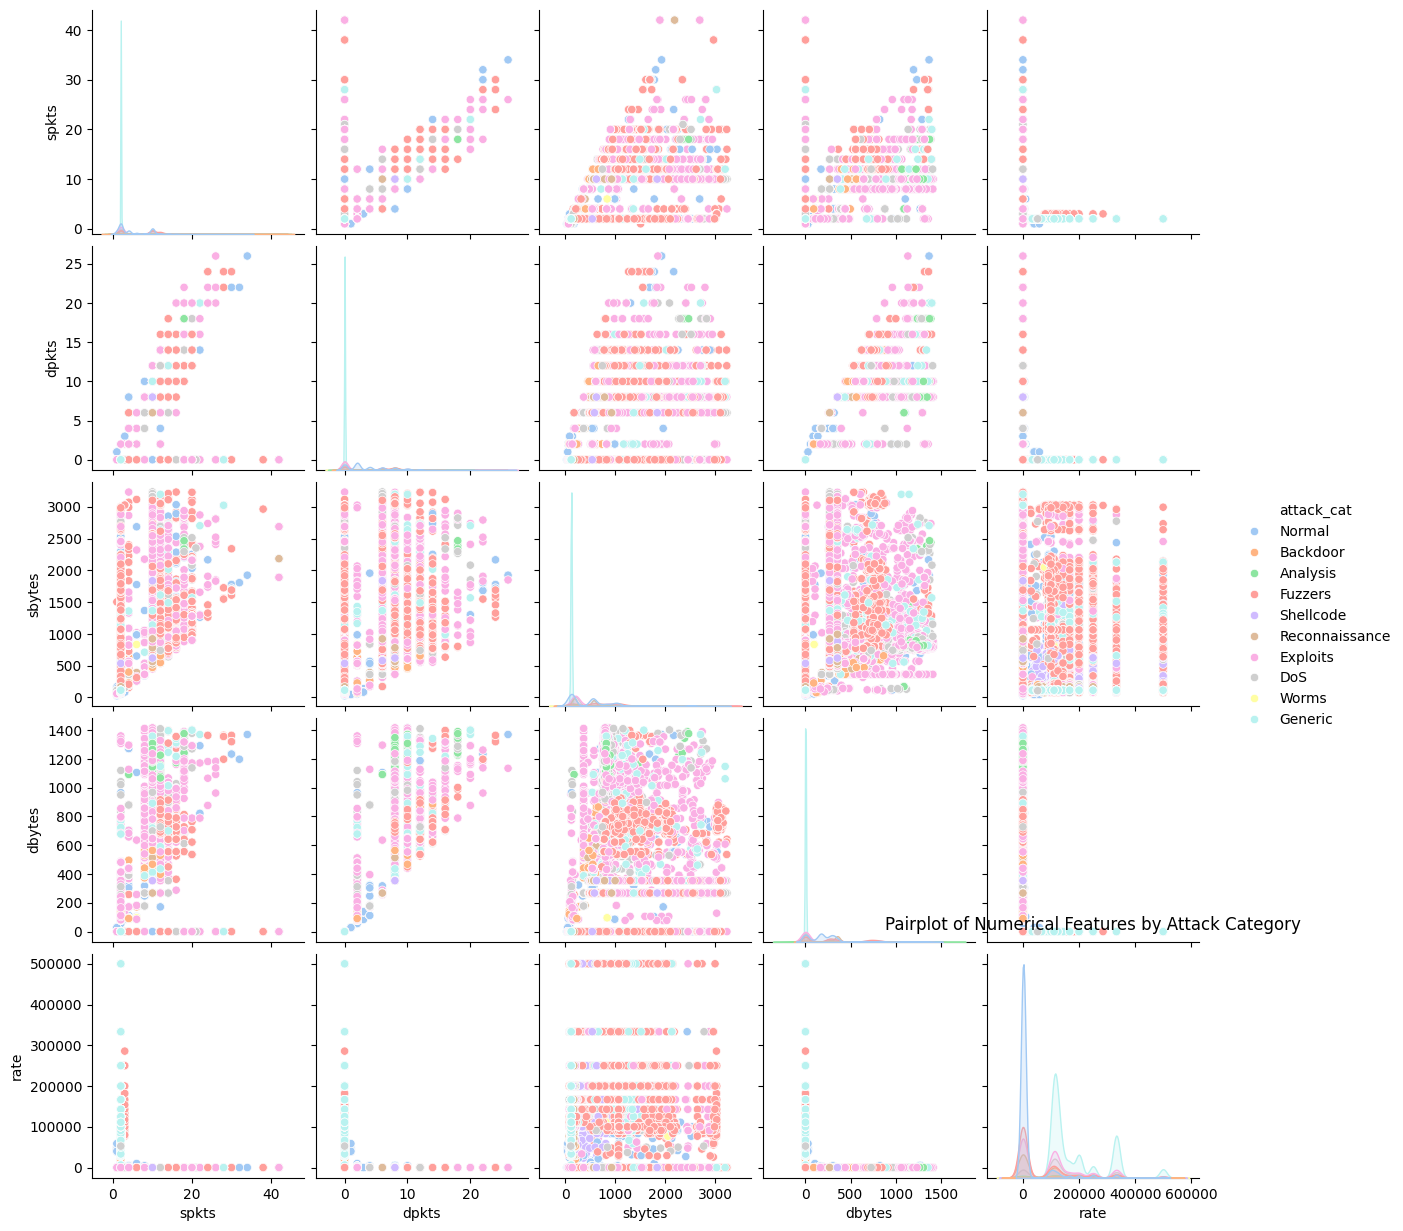

In [130]:
#plt.figure(figsize=(10, 8))
sns.pairplot(df[['spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'attack_cat']], hue='attack_cat', palette='pastel')
plt.title('Pairplot of Numerical Features by Attack Category')
plt.show()

**Feature Engineering: Adding Packet-to-Byte Ratio feature**

In [131]:
# Adding new Feature: packets per byte ratio , which can enhance the analysis
df['pkt_byte_ratio'] = df['spkts'] / df['sbytes']
df.shape


(124279, 45)

**Principal Component Analysis to reduce the dimensionality of the dataset and visualize patterns or clusters.**

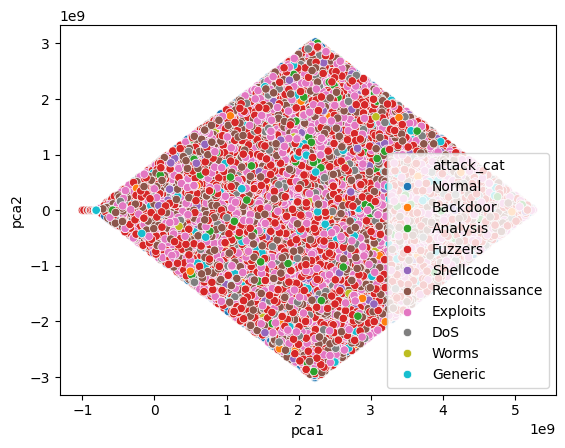

In [132]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.select_dtypes(include=[np.number]))
df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]
sns.scatterplot(x='pca1', y='pca2', hue='attack_cat', data=df)
plt.show()


**Encoding Categorical data**

In [133]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to all categorical columns
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col + '_encoded'] = label_encoder.fit_transform(df[col])
    df.drop(col, axis=1, inplace=True)
# Ensure 'label' column is encoded
if 'label' in df.columns and 'label_encoded' not in df.columns:
    df['label_encoded'] = label_encoder.fit_transform(df['label'])
    df.drop('label', axis=1, inplace=True)

**Data Normalization**

In [134]:
# Normalizing numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [135]:
# Dropping the 'id' column as it is not required
df.drop(columns=['id'], inplace=True)


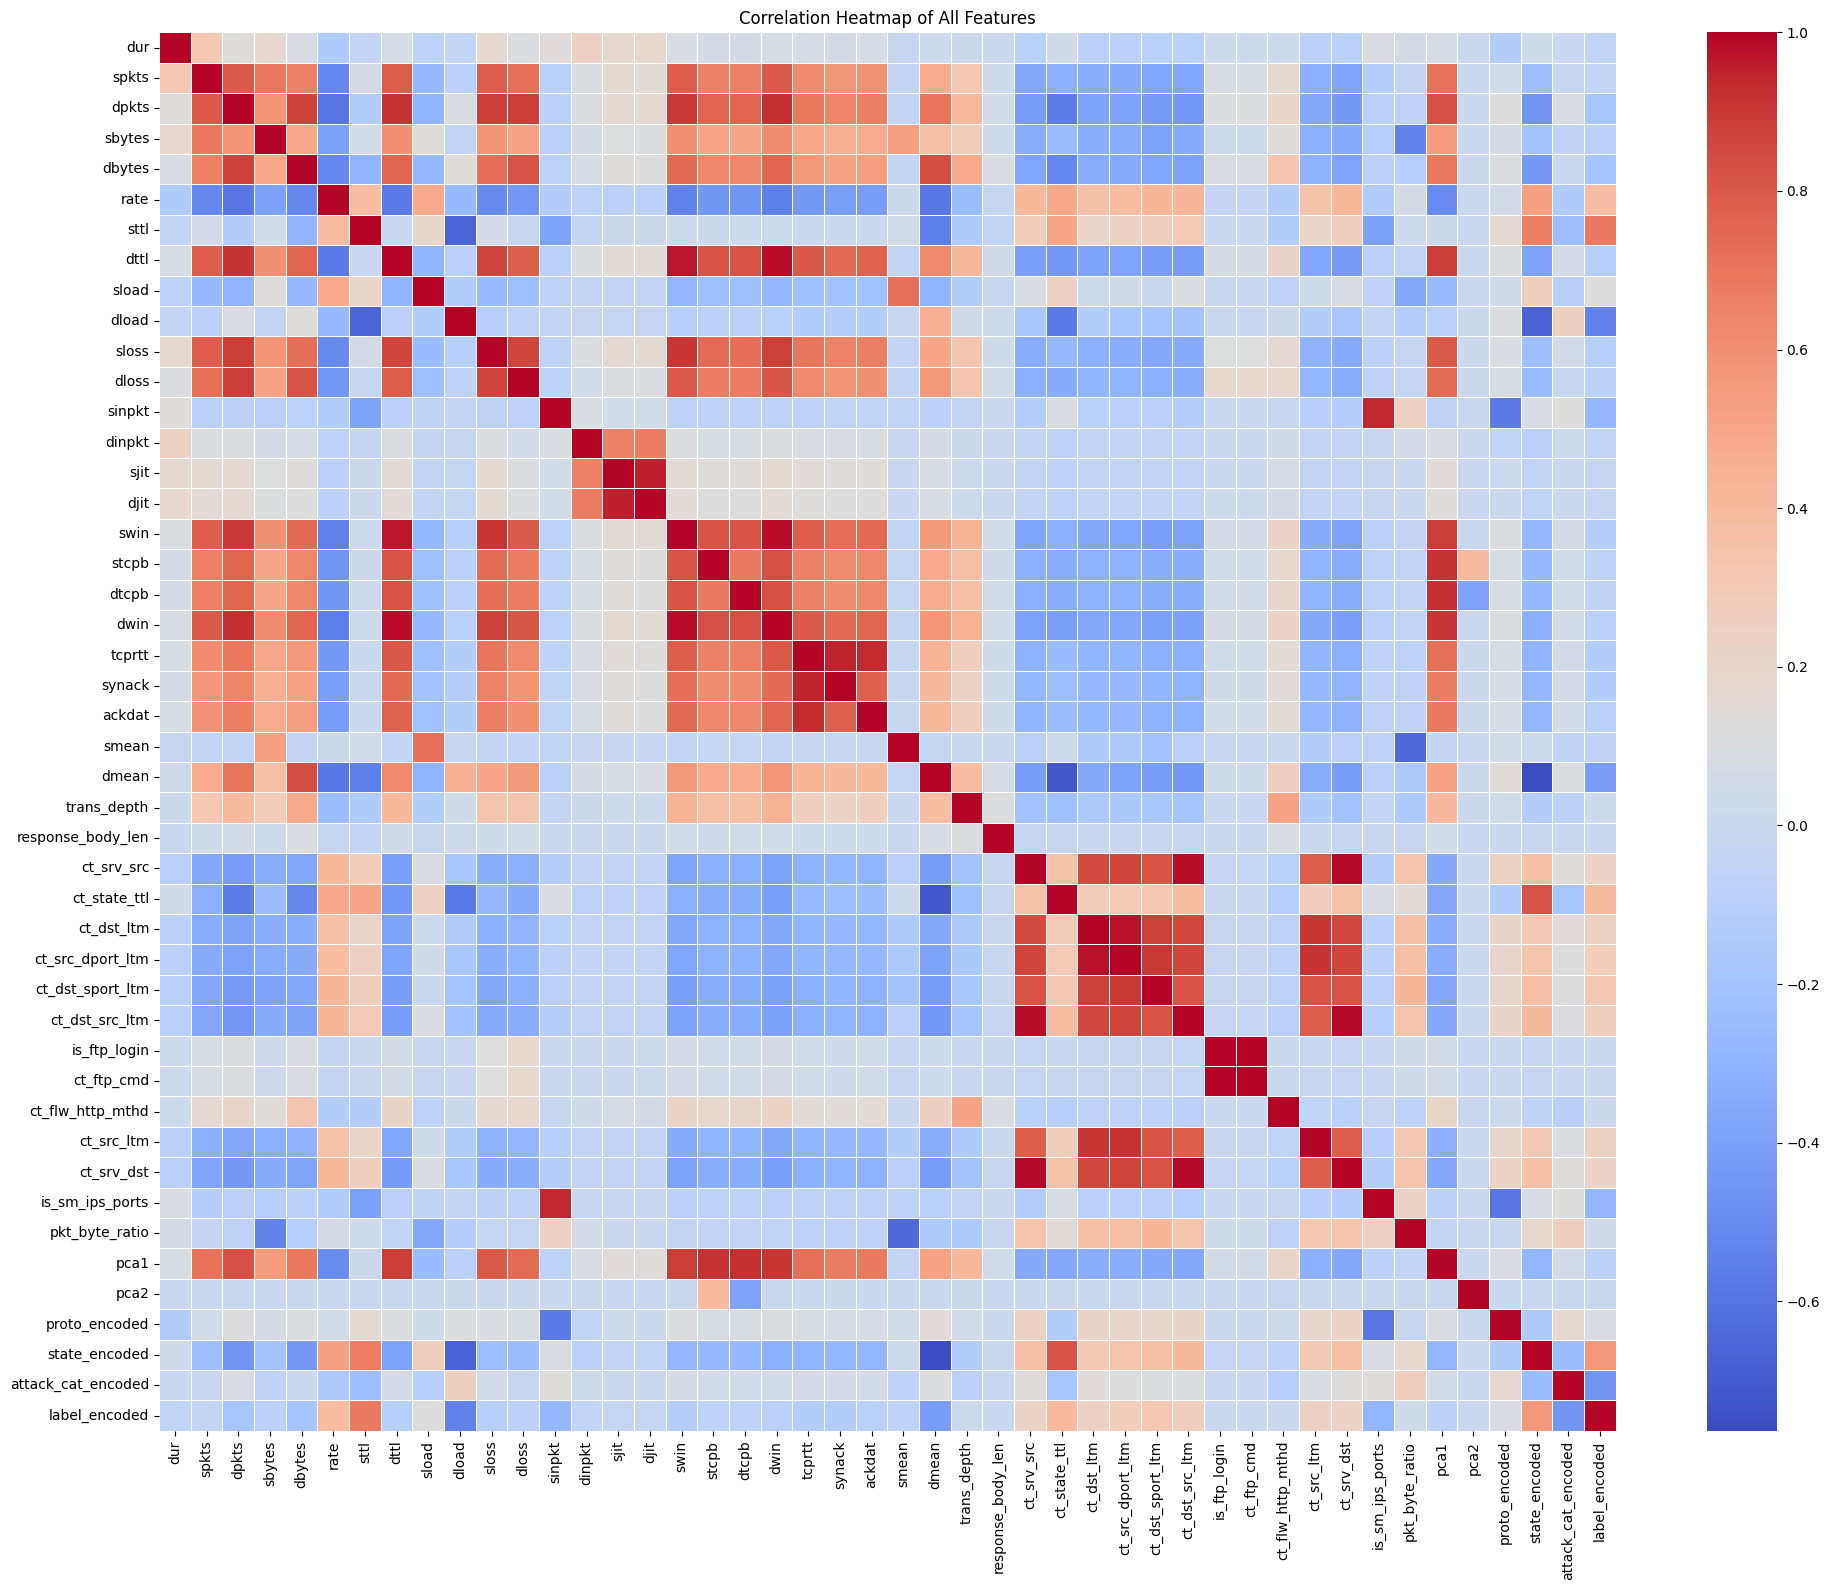

In [136]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot heatmap of the correlation matrix for all features
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()


Shape of binary classification dataset: (124279, 17)
Shape of multi-class classification dataset: (124279, 17)


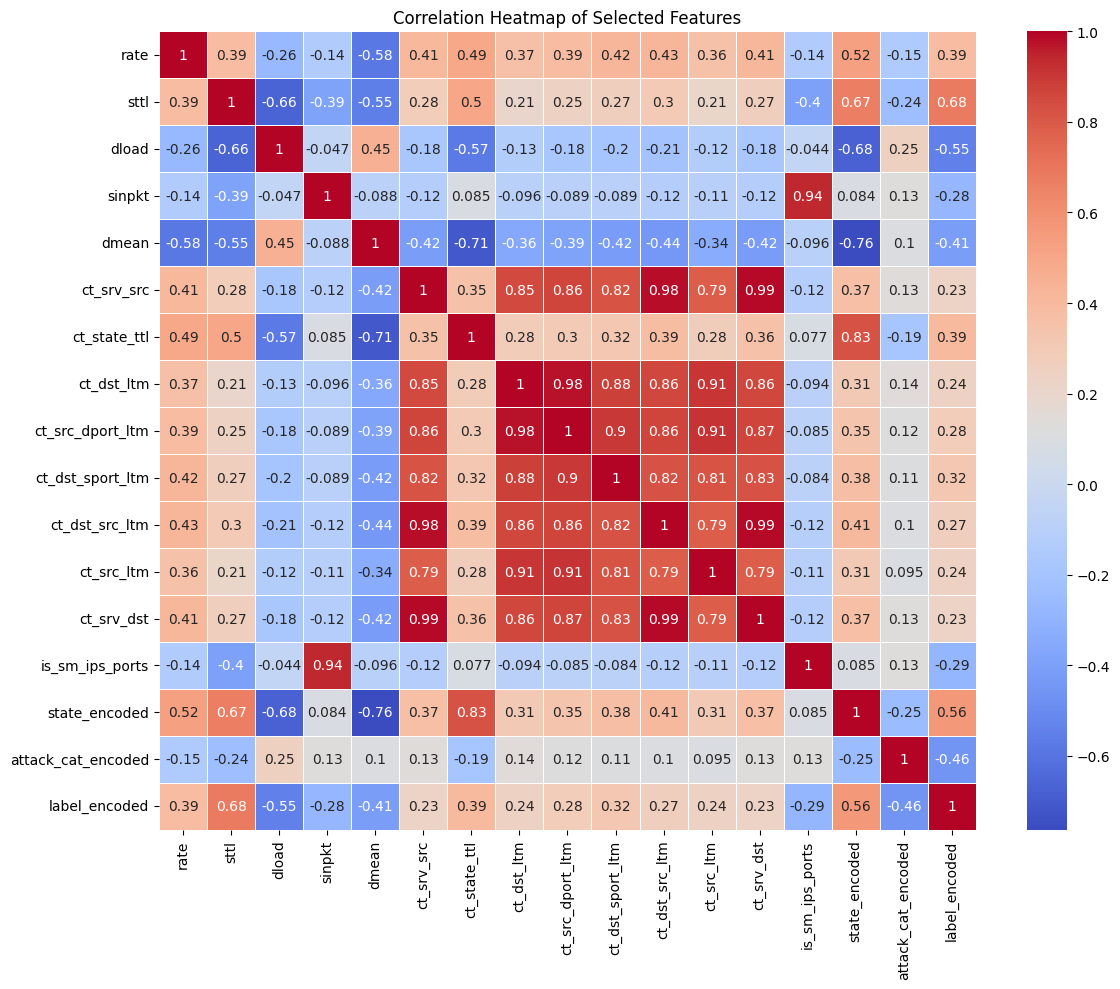


Selected features:
['rate', 'sttl', 'dload', 'sinpkt', 'dmean', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'state_encoded', 'attack_cat_encoded']


In [137]:
# Calculate correlations with the 'label_encoded' column
label_correlations = abs(correlation_matrix['label_encoded'])

# Select columns with correlation above 0.2 (excluding 'label_encoded' itself)
selected_columns = label_correlations[label_correlations > 0.2].index.tolist()
selected_columns.remove('label_encoded')

# Create a new DataFrame with only the selected columns for binary classification
df_selected_bin = df[selected_columns + ['label_encoded']]

# For multi-class classification, include 'attack_cat_encoded'
if 'attack_cat_encoded' in df.columns:
    df_selected_multi = df[selected_columns + ['attack_cat_encoded']]
else:
    df_selected_multi = df[selected_columns + ['label_encoded']]  # Use binary labels if multi-class not available

print("Shape of binary classification dataset:", df_selected_bin.shape)
print("Shape of multi-class classification dataset:", df_selected_multi.shape)

# Plot heatmap of the correlation matrix for selected features
plt.figure(figsize=(12, 10))
sns.heatmap(df_selected_bin.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features')
plt.tight_layout()
plt.show()

# Print the selected features
print("\nSelected features:")
print(selected_columns)

**Splitting data for Binary Classification**

In [138]:
X_binary = df_selected_bin.drop('label_encoded', axis=1)
y_binary = df_selected_bin['label_encoded']
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

print("\nBinary Classification:")
print("X_train shape:", X_train_binary.shape)
print("X_test shape:", X_test_binary.shape)
print("y_train shape:", y_train_binary.shape)
print("y_test shape:", y_test_binary.shape)


Binary Classification:
X_train shape: (99423, 16)
X_test shape: (24856, 16)
y_train shape: (99423,)
y_test shape: (24856,)


df_ = pd.read_csv('UNSW_NB15.csv')
df_ = df_.drop(columns=['proto'])
non_numeric_columns = df_.select_dtypes(include=['object']).columns

df_ = df_.drop(columns=non_numeric_columns)

X = df_.drop('label', axis=1)
y = df_['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **1. Linear Regression**

In [140]:
# Initialize the Linear Regression model
models_metrics = {}
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(X_train_binary, y_train_binary)

# Make predictions on the test set
predicted_values_linear = linear_reg_model.predict(X_test_binary)

# Round predictions to 0 or 1 for binary classification
rounded_predictions_linear = np.where(predicted_values_linear > 0.5, 1, 0)

In [141]:
# Calculate evaluation metrics
mae_linear = mean_absolute_error(y_test_binary, rounded_predictions_linear)
mse_linear = mean_squared_error(y_test_binary, rounded_predictions_linear)
rmse_linear = np.sqrt(mse_linear)
r2_score_linear = explained_variance_score(y_test_binary, rounded_predictions_linear) * 100
accuracy_linear = accuracy_score(y_test_binary, rounded_predictions_linear) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_linear)
print("Mean Squared Error:", mse_linear)
print("Root Mean Squared Error:", rmse_linear)
print("R² Score:", r2_score_linear)
print("Accuracy:", accuracy_linear)

Mean Absolute Error: 0.08062439652397811
Mean Squared Error: 0.08062439652397811
Root Mean Squared Error: 0.2839443546260043
R² Score: 56.110490511121704
Accuracy: 91.93756034760219


In [142]:
# Generate classification report
classification_report_str_linear = classification_report(y_true=y_test_binary, y_pred=rounded_predictions_linear)
print(classification_report_str_linear)


              precision    recall  f1-score   support

         0.0       0.98      0.64      0.78      5422
         1.0       0.91      1.00      0.95     19434

    accuracy                           0.92     24856
   macro avg       0.95      0.82      0.86     24856
weighted avg       0.93      0.92      0.91     24856



In [143]:
# Create a DataFrame for actual vs predicted values
import os
linear_predictions_df = pd.DataFrame({'Actual': y_test_binary, 'Predicted': rounded_predictions_linear})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
linear_predictions_df.to_csv(os.path.join(predictions_dir, 'linear_regression_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(linear_predictions_df)

        Actual  Predicted
65509      0.0          1
46055      0.0          1
89842      1.0          1
168922     1.0          1
114406     1.0          1
...        ...        ...
131021     1.0          1
46197      0.0          1
157647     1.0          1
352        0.0          0
125967     1.0          1

[24856 rows x 2 columns]


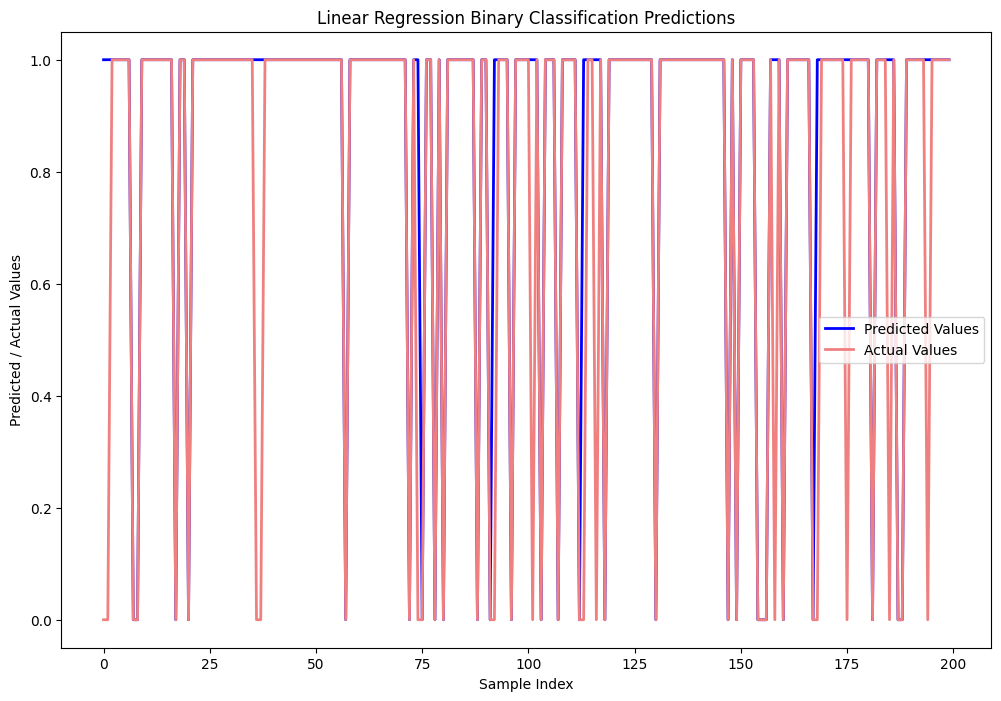

In [144]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(rounded_predictions_linear[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Linear Regression Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")

# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'linear_regression_predictions_plot.png'))
plt.show()

In [145]:
# Saving the trained Linear Regression model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_linear = path.join(weights_dir, "linear_regression_model.pkl")
if not path.isfile(model_filename_linear):
    with open(model_filename_linear, 'wb') as file:
        pickle.dump(linear_reg_model, file)
    print("Linear Regression model saved to disk.")
else:
    print("Previous Linear Regression model exists on the disk! Please remove it.")

Previous Linear Regression model exists on the disk! Please remove it.


In [146]:
# Collecting metrics for comparison later on
models_metrics["Linear Regression"] = {
    "Accuracy": accuracy_linear,
    "MAE": mae_linear,
    "MSE": mse_linear,
    "RMSE": rmse_linear,
    "R2 Score": r2_score_linear,
    "Predictions": rounded_predictions_linear,
}

 ## 2. Logistic Regression

In [ ]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],  # Inverse of regularization strength
    'penalty': ['l2'],         # Regularization type
}

# Initialize the Logistic Regression model
logistic_reg_model = LogisticRegression(random_state=123, max_iter=5000)


In [ ]:
# Perform hyperparameter tuning using GridSearchCV
grid_search = GridSearchCV(estimator=logistic_reg_model, param_grid=param_grid,
                           scoring='accuracy', cv=5, n_jobs=-1)
grid_search.fit(X_train_binary, y_train_binary)

# Get the best model from grid search
best_logistic_reg_model = grid_search.best_estimator_

# Predicting on the test set using the best model
y_pred_logistic = best_logistic_reg_model.predict(X_test_binary)


In [ ]:
# Calculate evaluation metrics
mae_logistic = mean_absolute_error(y_test_binary, y_pred_logistic)
mse_logistic = mean_squared_error(y_test_binary, y_pred_logistic)
rmse_logistic = np.sqrt(mse_logistic)
r2_score_logistic = explained_variance_score(y_test_binary, y_pred_logistic) * 100
accuracy_logistic = accuracy_score(y_test_binary, y_pred_logistic) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_logistic)
print("Mean Squared Error:", mse_logistic)
print("Root Mean Squared Error:", rmse_logistic)
print("R² Score:", r2_score_logistic)
print("Accuracy:", accuracy_logistic)


Mean Absolute Error: 0.08500965561635018
Mean Squared Error: 0.08500965561635018
Root Mean Squared Error: 0.2915641535174552
R² Score: 51.65118349094955
Accuracy: 91.49903443836497


In [ ]:
# Generate classification report
classification_report_str_logistic = classification_report(y_true=y_test_binary, y_pred=y_pred_logistic)
print(classification_report_str_logistic)

              precision    recall  f1-score   support

         0.0       0.90      0.69      0.78      5422
         1.0       0.92      0.98      0.95     19434

    accuracy                           0.91     24856
   macro avg       0.91      0.83      0.86     24856
weighted avg       0.91      0.91      0.91     24856



In [ ]:
# Create a DataFrame for actual vs predicted values
logistic_predictions_df = pd.DataFrame({'Actual': y_test_binary, 'Predicted': y_pred_logistic})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
logistic_predictions_df.to_csv(os.path.join(predictions_dir, 'logistic_regression_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(logistic_predictions_df)

        Actual  Predicted
65509      0.0        1.0
46055      0.0        0.0
89842      1.0        1.0
168922     1.0        1.0
114406     1.0        0.0
...        ...        ...
131021     1.0        1.0
46197      0.0        1.0
157647     1.0        1.0
352        0.0        0.0
125967     1.0        1.0

[24856 rows x 2 columns]


Text(0, 0.5, 'Predicted / Actual Values')

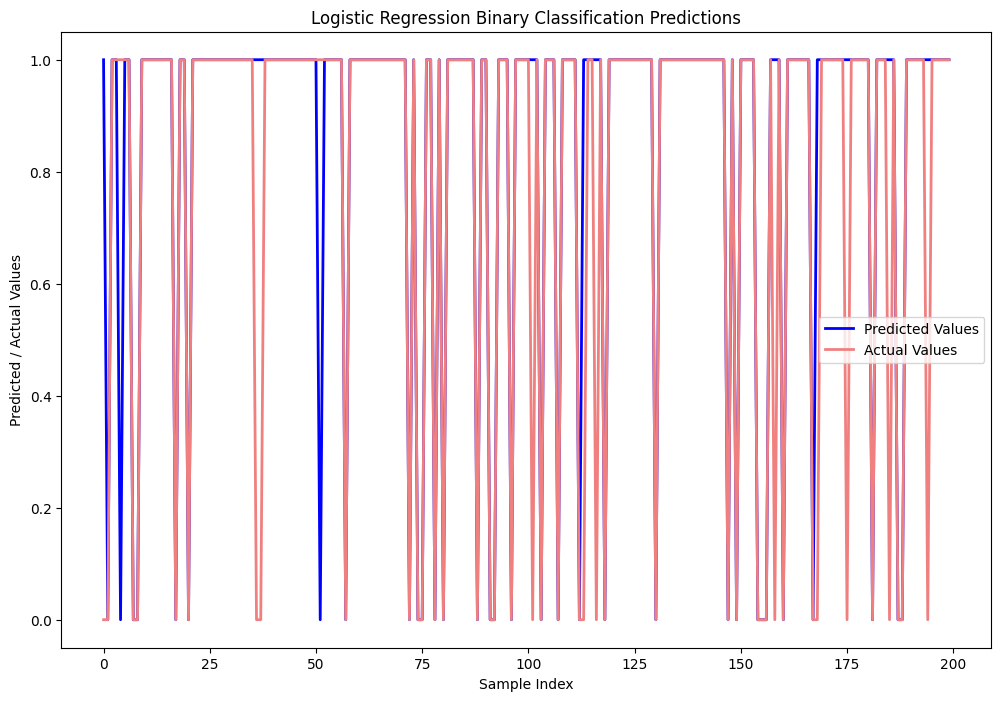

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_logistic[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Logistic Regression Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")


In [ ]:
# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'logistic_regression_predictions_plot.png'))
plt.show()

# Saving the trained Logistic Regression model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_logistic = path.join(weights_dir, "logistic_regression_model.pkl")
if not path.isfile(model_filename_logistic):
    with open(model_filename_logistic, 'wb') as file:
        pickle.dump(best_logistic_reg_model, file)
    print("Logistic Regression model saved to disk.")
else:
    print("Previous Logistic Regression model exists on the disk! Please remove it.")

<Figure size 640x480 with 0 Axes>

Previous Logistic Regression model exists on the disk! Please remove it.


In [ ]:
models_metrics["Logistic Regression"] = {
    "Accuracy": accuracy_logistic,
    "MAE": mae_logistic,
    "MSE": mse_logistic,
    "RMSE": rmse_logistic,
    "R2 Score": r2_score_logistic,
    "Predictions": y_pred_logistic
}


### **3. K Nearest Neighbor Classifier**

In [ ]:
# Initialize the K-Nearest Neighbors model
knn_model = KNeighborsClassifier()

# Define the parameter grid for hyperparameter tuning
param_grid_knn = {
    'n_neighbors': [5, 7, 9],  # Number of neighbors to use
   'weights': ['uniform', 'distance'],  # Weight function used in prediction
}

# Perform hyperparameter tuning using GridSearchCV
grid_search_knn = GridSearchCV(estimator=knn_model, param_grid=param_grid_knn,
                               scoring='accuracy', cv=5, n_jobs=-1)
grid_search_knn.fit(X_train_binary, y_train_binary)

# Get the best model from grid search
best_knn_model = grid_search_knn.best_estimator_

# Print the best parameters found by GridSearchCV
print("Best parameters for KNN:", grid_search_knn.best_params_)

# Predicting on the test set using the best model
y_pred_knn = best_knn_model.predict(X_test_binary)

Best parameters for KNN: {'n_neighbors': 5, 'weights': 'distance'}


In [ ]:
# Calculate evaluation metrics
mae_knn = mean_absolute_error(y_test_binary, y_pred_knn)
mse_knn = mean_squared_error(y_test_binary, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_score_knn = explained_variance_score(y_test_binary, y_pred_knn) * 100
accuracy_knn = accuracy_score(y_test_binary, y_pred_knn) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_knn)
print("Mean Squared Error:", mse_knn)
print("Root Mean Squared Error:", rmse_knn)
print("R² Score:", r2_score_knn)
print("Accuracy:", accuracy_knn)


Mean Absolute Error: 0.00048278081750885096
Mean Squared Error: 0.00048278081750885096
Root Mean Squared Error: 0.021972273835651396
R² Score: 99.71693200115843
Accuracy: 99.95172191824912


In [ ]:
# Generate classification report
classification_report_str_knn = classification_report(y_true=y_test_binary, y_pred=y_pred_knn)
print(classification_report_str_knn)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5422
         1.0       1.00      1.00      1.00     19434

    accuracy                           1.00     24856
   macro avg       1.00      1.00      1.00     24856
weighted avg       1.00      1.00      1.00     24856



In [ ]:
# Create a DataFrame for actual vs predicted values
knn_predictions_df = pd.DataFrame({'Actual': y_test_binary, 'Predicted': y_pred_knn})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
knn_predictions_df.to_csv(os.path.join(predictions_dir, 'knn_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(knn_predictions_df)

        Actual  Predicted
65509      0.0        0.0
46055      0.0        0.0
89842      1.0        1.0
168922     1.0        1.0
114406     1.0        1.0
...        ...        ...
131021     1.0        1.0
46197      0.0        0.0
157647     1.0        1.0
352        0.0        0.0
125967     1.0        1.0

[24856 rows x 2 columns]


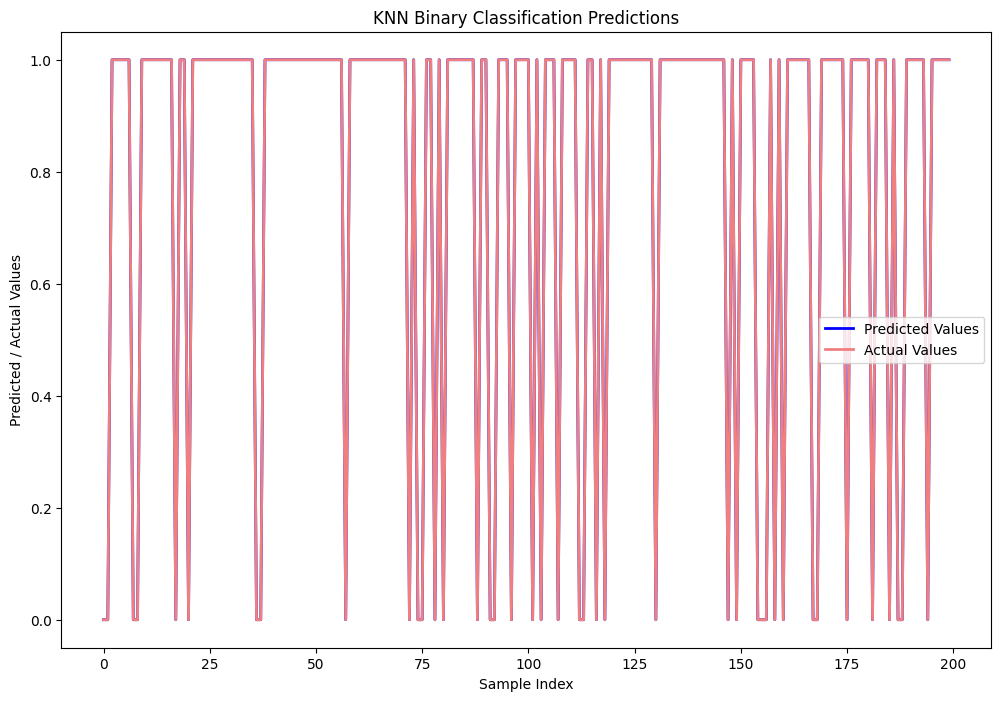

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_knn[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("KNN Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")


# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'knn_predictions_plot.png'))
plt.show()


In [ ]:
# Saving the trained KNN model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_knn = path.join(weights_dir, "knn_model.pkl")
if not path.isfile(model_filename_knn):
    with open(model_filename_knn, 'wb') as file:
        pickle.dump(best_knn_model, file)
    print("KNN model saved to disk.")
else:
    print("Previous KNN model exists on the disk! Please remove it.")


Previous KNN model exists on the disk! Please remove it.


In [ ]:
models_metrics["KNN"] = {
    "Accuracy": accuracy_knn,
    "MAE": mae_knn,
    "MSE": mse_knn,
    "RMSE": rmse_knn,
    "R2 Score": r2_score_knn,
    "Predictions": y_pred_knn
}


### **4. Linear Support Vector Machine**

In [ ]:
# Initialize the Linear Support Vector Machine model
lsvm_model = SVC(kernel='linear', gamma='auto')

# Train the model
lsvm_model.fit(X_train_binary, y_train_binary)

# Predicting on the test set
y_pred_lsvm = lsvm_model.predict(X_test_binary)



In [ ]:
# Calculate evaluation metrics
mae_lsvm = mean_absolute_error(y_test_binary, y_pred_lsvm)
mse_lsvm = mean_squared_error(y_test_binary, y_pred_lsvm)
rmse_lsvm = np.sqrt(mse_lsvm)
r2_score_lsvm = explained_variance_score(y_test_binary, y_pred_lsvm) * 100
accuracy_lsvm = accuracy_score(y_test_binary, y_pred_lsvm) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_lsvm)
print("Mean Squared Error:", mse_lsvm)
print("Root Mean Squared Error:", rmse_lsvm)
print("R² Score:", r2_score_lsvm)
print("Accuracy:", accuracy_lsvm)

Mean Absolute Error: 0.0747505632442871
Mean Squared Error: 0.0747505632442871
Root Mean Squared Error: 0.27340549234477185
R² Score: 58.86294035631083
Accuracy: 92.5249436755713


In [ ]:
# Generate classification report
classification_report_str_lsvm = classification_report(y_true=y_test_binary, y_pred=y_pred_lsvm)
print(classification_report_str_lsvm)


              precision    recall  f1-score   support

         0.0       0.98      0.67      0.80      5422
         1.0       0.92      1.00      0.95     19434

    accuracy                           0.93     24856
   macro avg       0.95      0.83      0.88     24856
weighted avg       0.93      0.93      0.92     24856



In [ ]:
# Create a DataFrame for actual vs predicted values
lsvm_predictions_df = pd.DataFrame({'Actual': y_test_binary, 'Predicted': y_pred_lsvm})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
lsvm_predictions_df.to_csv(os.path.join(predictions_dir, 'lsvm_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(lsvm_predictions_df)

        Actual  Predicted
65509      0.0        1.0
46055      0.0        0.0
89842      1.0        1.0
168922     1.0        1.0
114406     1.0        1.0
...        ...        ...
131021     1.0        1.0
46197      0.0        1.0
157647     1.0        1.0
352        0.0        0.0
125967     1.0        1.0

[24856 rows x 2 columns]


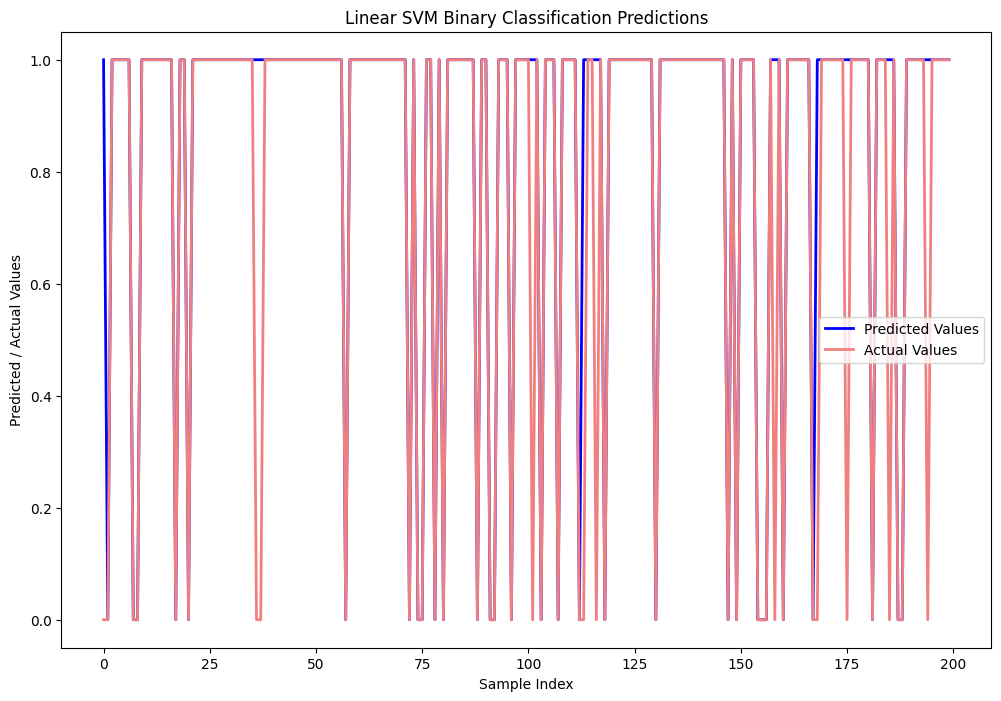

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_lsvm[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Linear SVM Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")

# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'lsvm_predictions_plot.png'))
plt.show()

In [ ]:
# Saving the trained Linear SVM model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_lsvm = path.join(weights_dir, "lsvm_model.pkl")
if not path.isfile(model_filename_lsvm):
    with open(model_filename_lsvm, 'wb') as file:
        pickle.dump(lsvm_model, file)
    print("Linear SVM model saved to disk.")
else:
    print("Previous Linear SVM model exists on the disk! Please remove it.")


Previous Linear SVM model exists on the disk! Please remove it.


In [ ]:
models_metrics["SVM"] = {
    "Accuracy": accuracy_lsvm,
    "MAE": mae_lsvm,
    "MSE": mse_lsvm,
    "RMSE": rmse_lsvm,
    "R2 Score": r2_score_lsvm,
    "Predictions": y_pred_lsvm
}

### **5. Naive Bayes Classifier**

In [ ]:
# Initialize the Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB
nb_classifier = GaussianNB()

# Train the model
nb_classifier.fit(X_train_binary, y_train_binary)

# Predicting on the test set
y_pred_nb = nb_classifier.predict(X_test_binary)

In [ ]:
# Calculate evaluation metrics
mae_nb = mean_absolute_error(y_test_binary, y_pred_nb)
mse_nb = mean_squared_error(y_test_binary, y_pred_nb)
rmse_nb = np.sqrt(mse_nb)
r2_score_nb = explained_variance_score(y_test_binary, y_pred_nb) * 100
accuracy_nb = accuracy_score(y_test_binary, y_pred_nb) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_nb)
print("Mean Squared Error:", mse_nb)
print("Root Mean Squared Error:", rmse_nb)
print("R² Score:", r2_score_nb)
print("Accuracy:", accuracy_nb)

Mean Absolute Error: 0.07277920823945928
Mean Squared Error: 0.07277920823945928
Root Mean Squared Error: 0.26977621881748454
R² Score: 60.43316999829973
Accuracy: 92.72207917605407


In [ ]:
# Generate classification report
classification_report_str_nb = classification_report(y_true=y_test_binary, y_pred=y_pred_nb)
print(classification_report_str_nb)

              precision    recall  f1-score   support

         0.0       1.00      0.67      0.80      5422
         1.0       0.91      1.00      0.96     19434

    accuracy                           0.93     24856
   macro avg       0.96      0.83      0.88     24856
weighted avg       0.93      0.93      0.92     24856



In [ ]:
# Create a DataFrame for actual vs predicted values
nb_predictions_df = pd.DataFrame({'Actual': y_test_binary, 'Predicted': y_pred_nb})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
nb_predictions_df.to_csv(os.path.join(predictions_dir, 'naive_bayes_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(nb_predictions_df)

        Actual  Predicted
65509      0.0        1.0
46055      0.0        0.0
89842      1.0        1.0
168922     1.0        1.0
114406     1.0        1.0
...        ...        ...
131021     1.0        1.0
46197      0.0        1.0
157647     1.0        1.0
352        0.0        0.0
125967     1.0        1.0

[24856 rows x 2 columns]


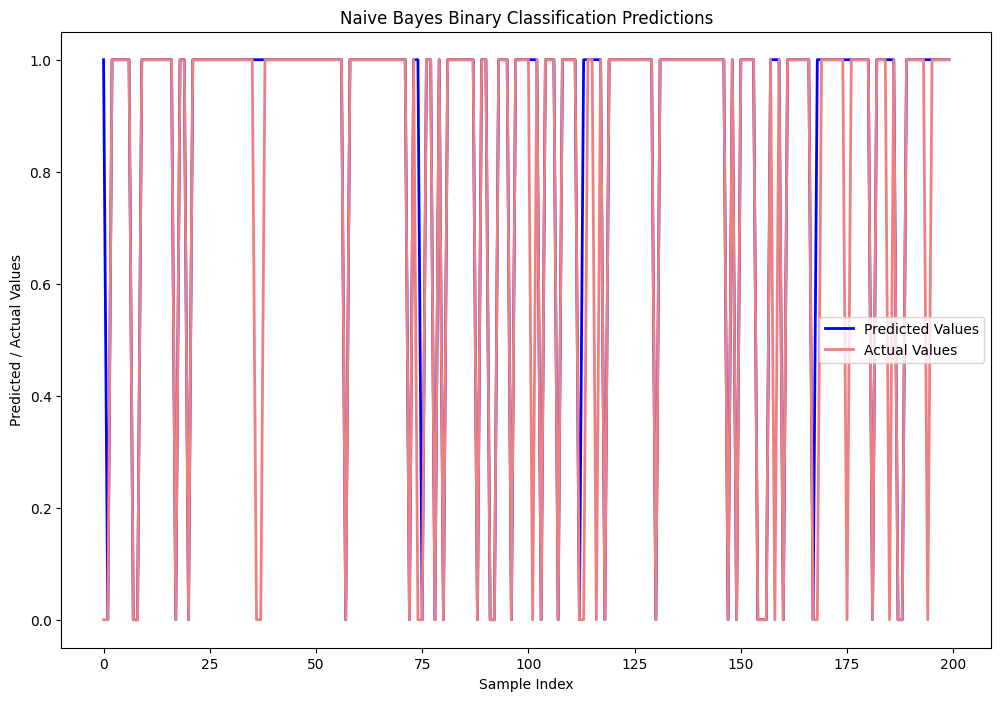

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_nb[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Naive Bayes Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")

# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'naive_bayes_predictions_plot.png'))
plt.show()


In [ ]:
# Saving the trained Naive Bayes model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_nb = path.join(weights_dir, "naive_bayes_model.pkl")
if not path.isfile(model_filename_nb):
    with open(model_filename_nb, 'wb') as file:
        pickle.dump(nb_classifier, file)
    print("Naive Bayes model saved to disk.")
else:
    print("Previous Naive Bayes model exists on the disk! Please remove it.")

Previous Naive Bayes model exists on the disk! Please remove it.


In [ ]:
models_metrics["Naive Bayes"] = {
    "Accuracy": accuracy_nb,
    "MAE": mae_nb,
    "MSE": mse_nb,
    "RMSE": rmse_nb,
    "R2 Score": r2_score_nb,
    "Predictions": y_pred_nb
}


### **6. Gradient Boosting**

In [ ]:
# Initialize the Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(random_state=123)

# Train the model
gb_classifier.fit(X_train, y_train)

# Predicting on the test set
y_pred_gb = gb_classifier.predict(X_test)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
# Calculate evaluation metrics
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_score_gb = explained_variance_score(y_test, y_pred_gb) * 100
accuracy_gb = accuracy_score(y_test, y_pred_gb) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_gb)
print("Mean Squared Error:", mse_gb)
print("Root Mean Squared Error:", rmse_gb)
print("R² Score:", r2_score_gb)
print("Accuracy:", accuracy_gb)

Mean Absolute Error: 0.020416892412101855
Mean Squared Error: 0.020416892412101855
Root Mean Squared Error: 0.14288769160463702
R² Score: 90.71873697034268
Accuracy: 97.9583107587898


In [ ]:
# Generate classification report
classification_report_str_gb = classification_report(y_true=y_test, y_pred=y_pred_gb)
print(classification_report_str_gb)

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     11169
           1       0.97      1.00      0.99     23900

    accuracy                           0.98     35069
   macro avg       0.98      0.97      0.98     35069
weighted avg       0.98      0.98      0.98     35069



In [ ]:
# Create a DataFrame for actual vs predicted values
import os
gb_predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_gb})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
gb_predictions_df.to_csv(os.path.join(predictions_dir, 'gradient_boosting_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(gb_predictions_df)

        Actual  Predicted
15482        0          0
133349       1          1
80485        1          1
29972        0          0
18339        0          0
...        ...        ...
94427        1          1
2244         0          0
17130        0          0
14327        0          0
60474        1          1

[35069 rows x 2 columns]


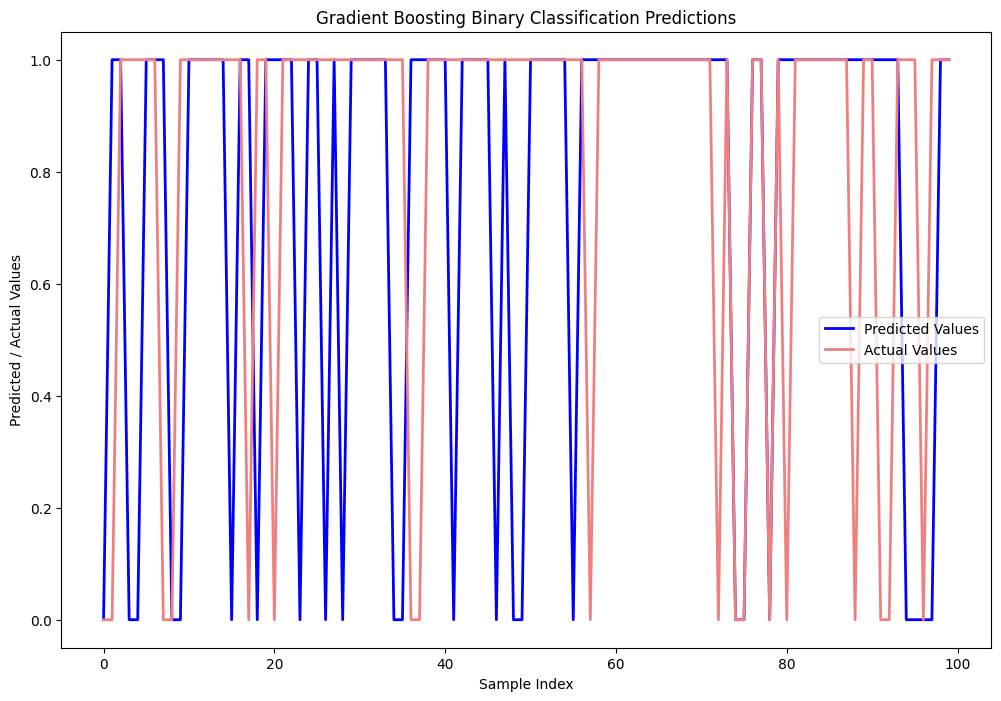

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_gb[:100], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test_binary[:100].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Gradient Boosting Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")

# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'gradient_boosting_predictions_plot.png'))
plt.show()

In [ ]:
# Saving the trained Gradient Boosting model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_gb = path.join(weights_dir, "gradient_boosting_model.pkl")
if not path.isfile(model_filename_gb):
    with open(model_filename_gb, 'wb') as file:
        pickle.dump(gb_classifier, file)
    print("Gradient Boosting model saved to disk.")
else:
    print("Previous Gradient Boosting model exists on the disk! Please remove it.")

Previous Gradient Boosting model exists on the disk! Please remove it.


In [ ]:
# Collecting metrics for comparison later on (assuming models_metrics is already defined)
models_metrics["Gradient Boosting"] = {
    "Accuracy": accuracy_gb,
    "MAE": mae_gb,
    "MSE": mse_gb,
    "RMSE": rmse_gb,
    "R2 Score": r2_score_gb,
    "Predictions": y_pred_gb
}

**7. Random Forest**

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Predicting on the test set
y_pred_rf = rf_classifier.predict(X_test)


In [ ]:
# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_score_rf = explained_variance_score(y_test, y_pred_rf) * 100
accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100

# Print evaluation metrics
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R² Score:", r2_score_rf)
print("Accuracy:", accuracy_rf)

Mean Absolute Error: 0.011092417804898913
Mean Squared Error: 0.011092417804898913
Root Mean Squared Error: 0.105320547875991
R² Score: 94.91786104021479
Accuracy: 98.8907582195101


In [ ]:
# Generate classification report
classification_report_str_rf = classification_report(y_true=y_test, y_pred=y_pred_rf)
print(classification_report_str_rf)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11169
           1       0.99      1.00      0.99     23900

    accuracy                           0.99     35069
   macro avg       0.99      0.98      0.99     35069
weighted avg       0.99      0.99      0.99     35069



In [ ]:
# Create a DataFrame for actual vs predicted values
rf_predictions_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_rf})

# Create 'predictions' directory if it doesn't exist
predictions_dir = './predictions'
if not os.path.exists(predictions_dir):
    os.makedirs(predictions_dir)

# Save the predictions DataFrame to a CSV file
rf_predictions_df.to_csv(os.path.join(predictions_dir, 'random_forest_predictions.csv'), index=False)

# Display the DataFrame with predictions
print(rf_predictions_df)


        Actual  Predicted
15482        0          0
133349       1          1
80485        1          1
29972        0          0
18339        0          0
...        ...        ...
94427        1          1
2244         0          0
17130        0          0
14327        0          0
60474        1          1

[35069 rows x 2 columns]


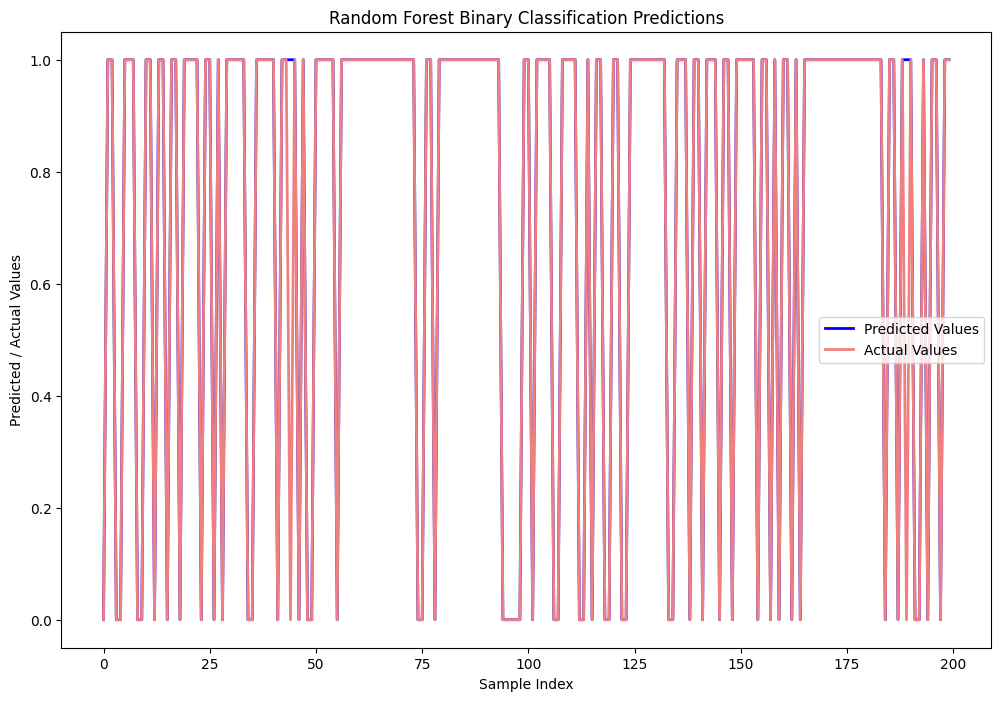

In [ ]:
# Create 'plots' directory if it doesn't exist
plots_dir = './plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)

# Plotting the predicted vs actual values for the first 200 instances
plt.figure(figsize=(12, 8))
plt.plot(y_pred_rf[:200], label="Predicted Values", linewidth=2.0, color='blue')
plt.plot(y_test[:200].values, label="Actual Values", linewidth=2.0, color='lightcoral')
plt.legend(loc="best")
plt.title("Random Forest Binary Classification Predictions")
plt.xlabel("Sample Index")
plt.ylabel("Predicted / Actual Values")

# Save the plot to a file
plt.savefig(os.path.join(plots_dir, 'random_forest_predictions_plot.png'))
plt.show()

In [ ]:
# Saving the trained Random Forest model to disk
weights_dir = './weights'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_filename_rf = path.join(weights_dir, "random_forest_model.pkl")
if not path.isfile(model_filename_rf):
    with open(model_filename_rf, 'wb') as file:
        pickle.dump(rf_classifier, file)
    print("Random Forest model saved to disk.")
else:
    print("Previous Random Forest model exists on the disk! Please remove it.")


Previous Random Forest model exists on the disk! Please remove it.


In [ ]:
models_metrics["Random Forest"] = {
    "Accuracy": accuracy_rf,
    "MAE": mae_rf,
    "MSE": mse_rf,
    "RMSE": rmse_rf,
    "R2 Score": r2_score_rf,
    "Predictions": y_pred_rf
}

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/3504936354.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mse_scores, palette='Reds_d')


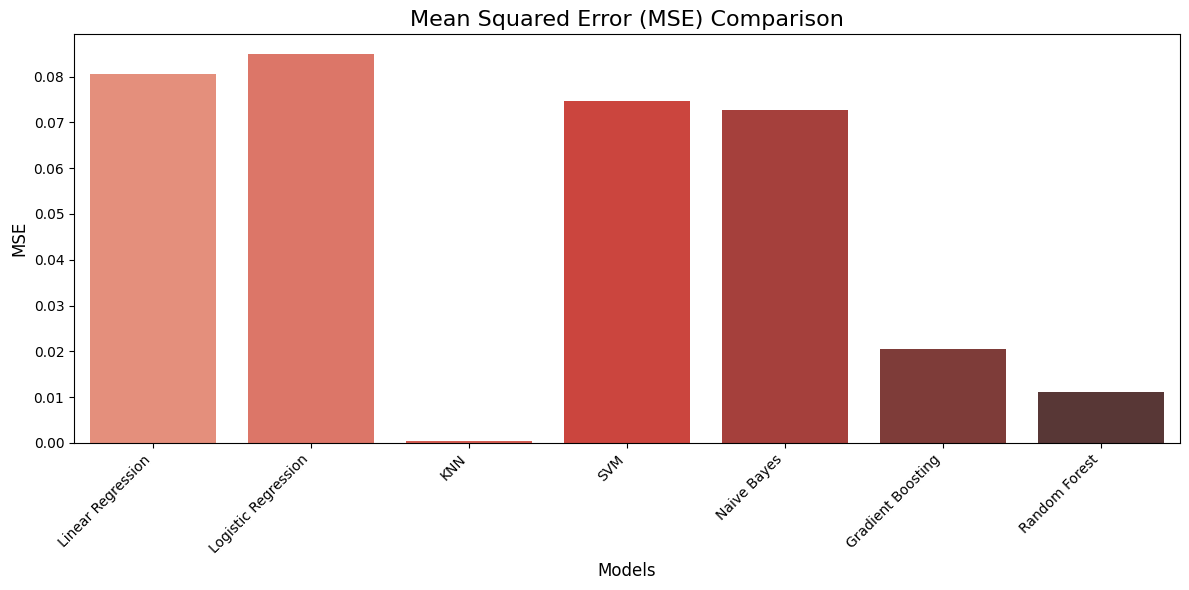

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extracting metrics from models_metrics
model_names = list(models_metrics.keys())
mse_scores = [metrics["MSE"] for metrics in models_metrics.values()]
r2_scores = [metrics["R2 Score"] for metrics in models_metrics.values()]

# Plot MSE Scores
plt.figure(figsize=(12, 6))
sns.barplot(x=model_names, y=mse_scores, palette='Reds_d')
plt.title("Mean Squared Error (MSE) Comparison", fontsize=16)
plt.xlabel("Models", fontsize=12)
plt.ylabel("MSE", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/1032893448.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_scores, palette='Blues_d')


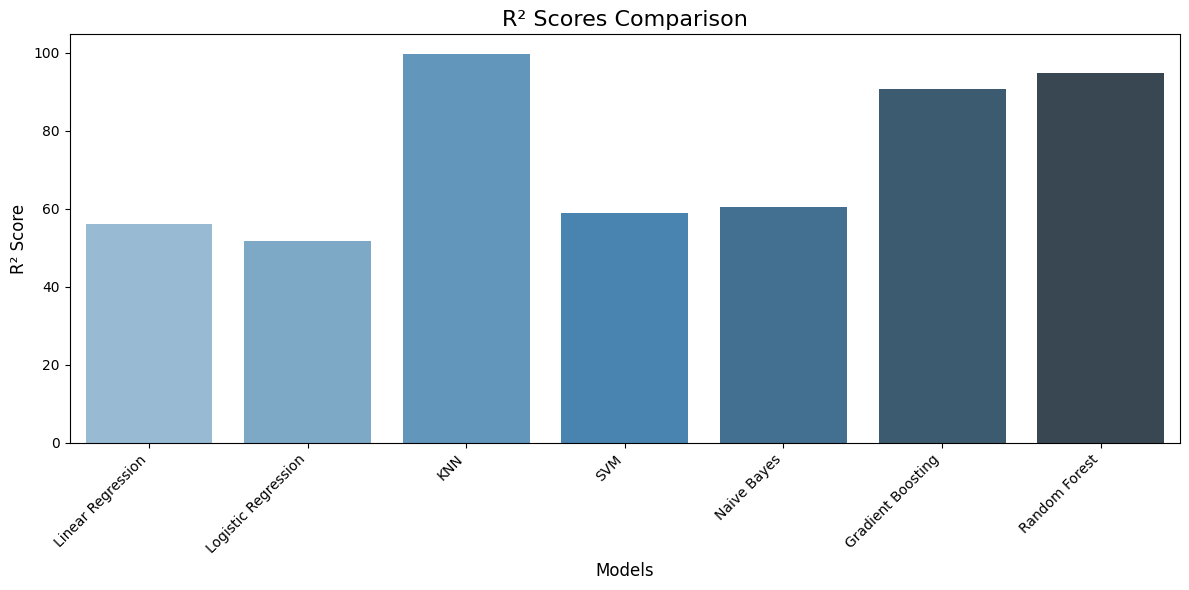

In [ ]:
# Plot R² Scores
plt.figure(figsize=(12, 6))
sns.barplot(x=model_names, y=r2_scores, palette='Blues_d')
plt.title("R² Scores Comparison", fontsize=16)
plt.xlabel("Models", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/var/folders/pt/5gvpztt535db9kjdnxy1jjsw0000gn/T/ipykernel_4527/721644545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


(0.0, 100.0)

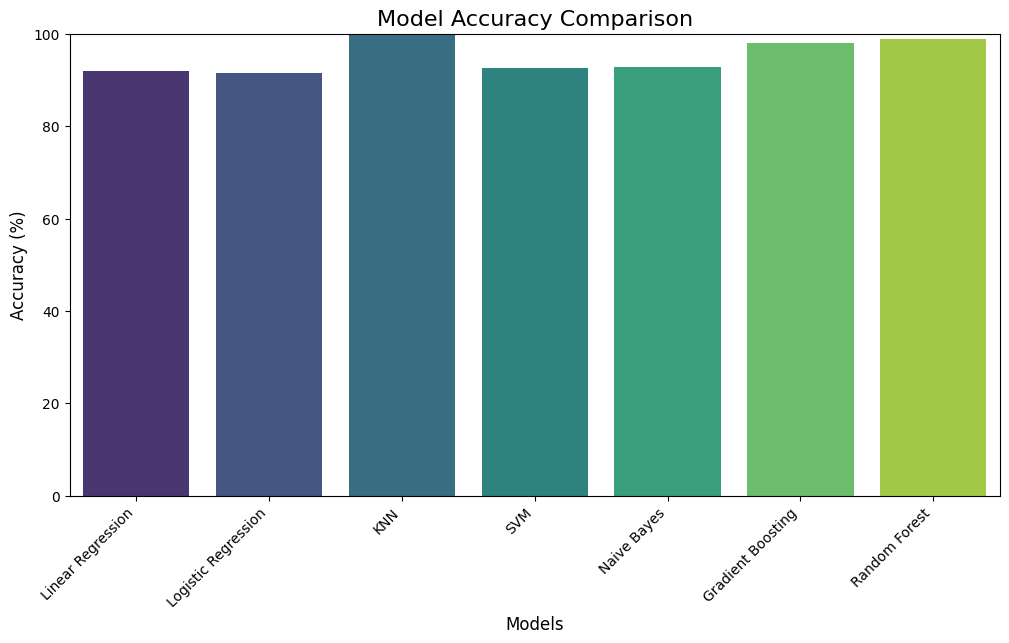

In [ ]:
# Accuracy Plot
plt.figure(figsize=(12, 6))
accuracy_scores = [metrics["Accuracy"] for metrics in models_metrics.values()]
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # Set y-axis from 0 to 100%